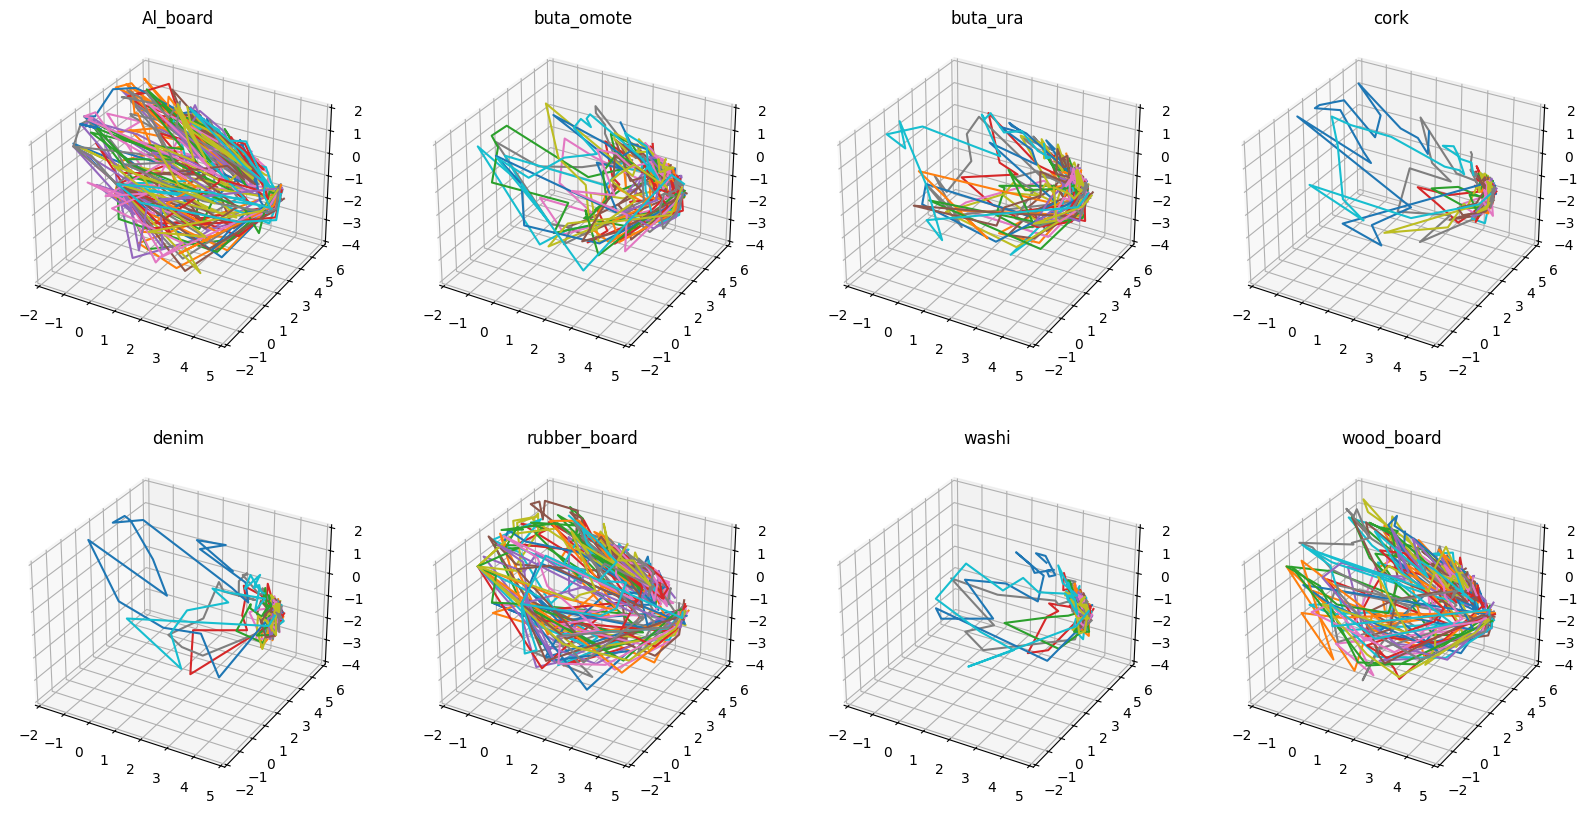

(8, 3) (8, 800) (800, 3)


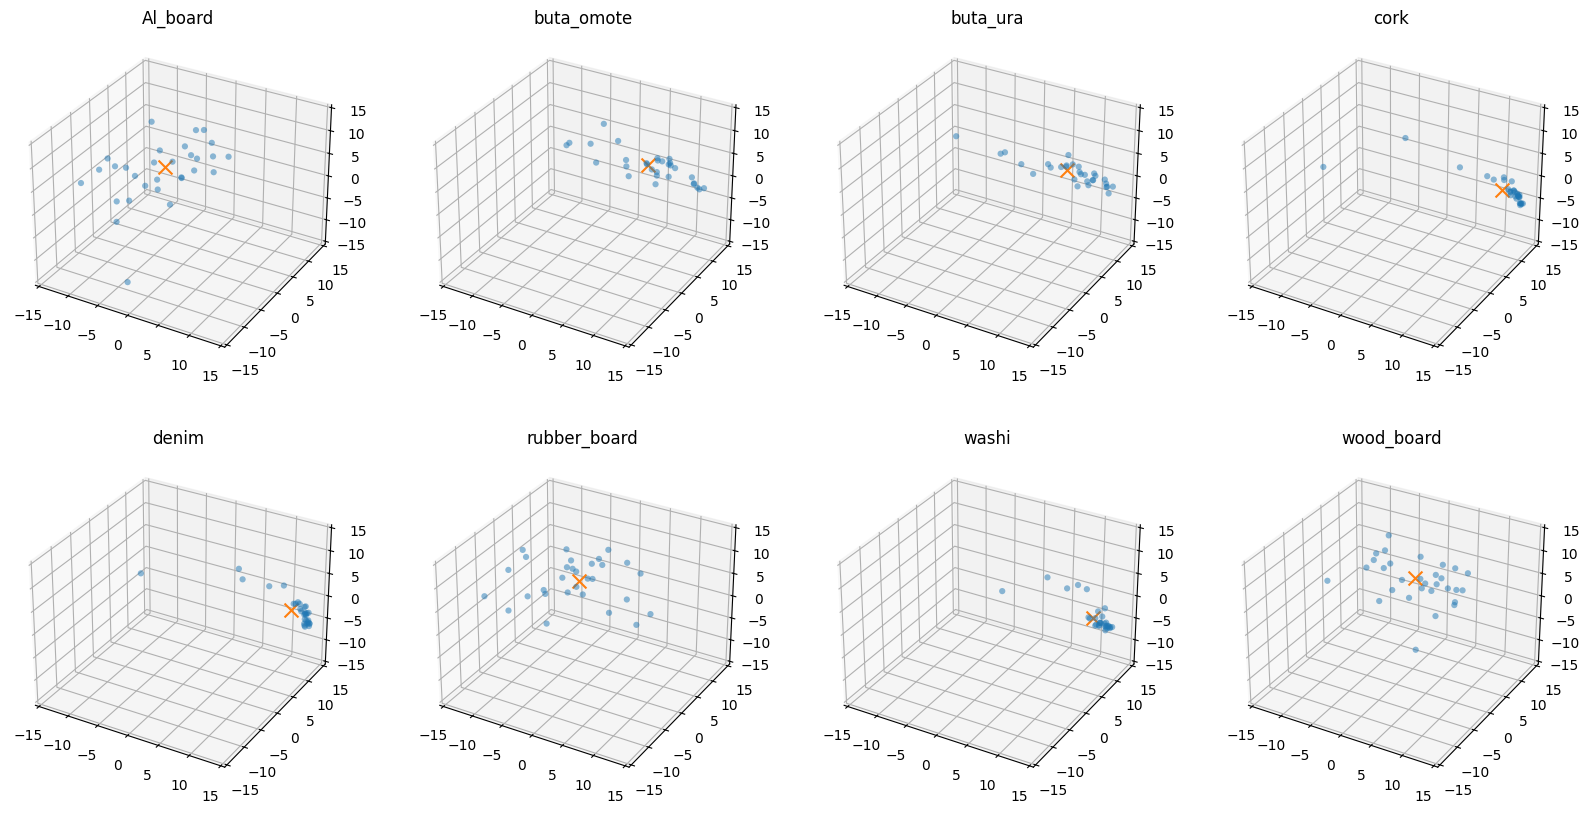

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


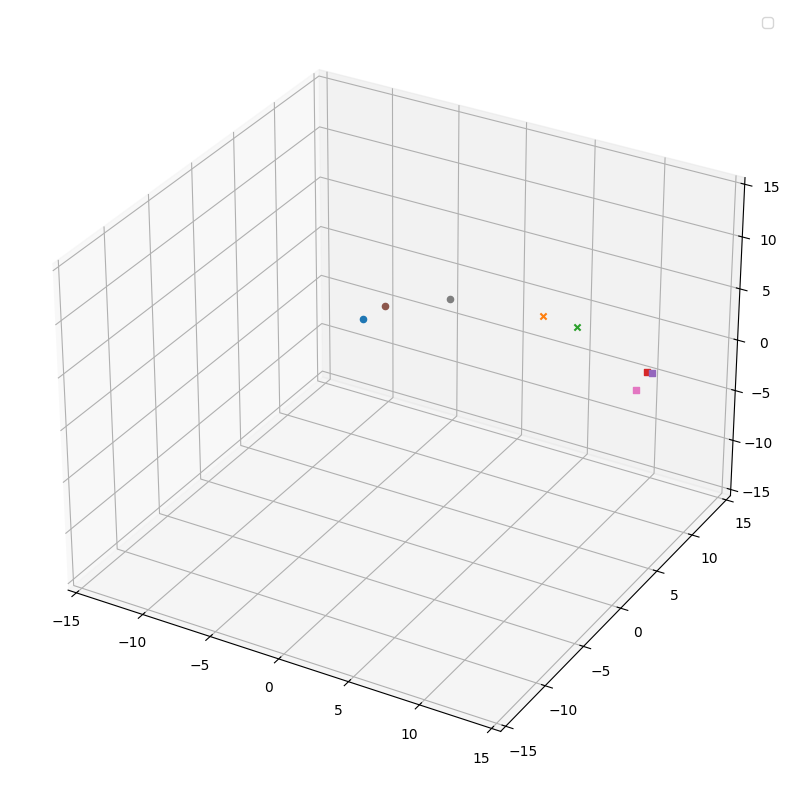

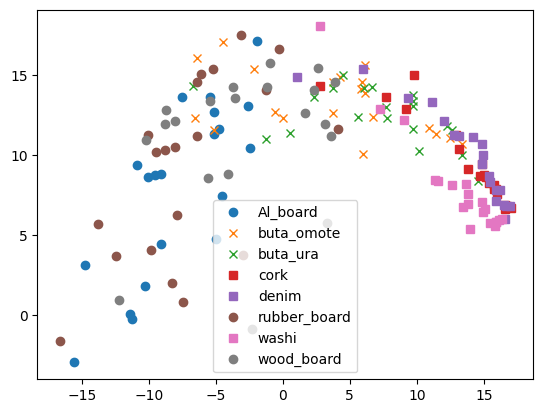

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

rng = np.random.default_rng(1)

dir_name = ["Al_board", "buta_omote", "buta_ura", "cork", "denim", "rubber_board", "washi", "wood_board"]

T_n = 25

sout_org = np.load('/Users/elast/OneDrive/デスクトップ/卒業研究/研究コード/kitano_LSM/sout_rec1.npy')

n_sozai = sout_org.shape[0]
n_sample = sout_org.shape[1]
N_out = sout_org.shape[2]
T = sout_org.shape[3]
n_interval = int(T/T_n)

sample_for_cls = 80
sample_for_tst = n_sample - sample_for_cls



sout_fr = np.zeros([n_sozai, sample_for_cls, N_out*n_interval])
sout_fr2 = np.zeros([n_sozai, sample_for_cls, N_out, n_interval])
sout_ave = np.zeros([n_sozai, N_out*n_interval])
sout_cov = np.zeros([n_sozai, N_out*n_interval, N_out*n_interval])
cov_mtrx = np.zeros([n_sozai, N_out*n_interval, N_out*n_interval])

# plt.imshow(sout_org[3, 99, 0:40, :], cmap='gray',aspect='auto')
# plt.show()

#print(sout_org[0,0,1,:])

loop_size = 10
for loop_i in range(loop_size):
    sout_rec = rng.permutation(sout_org,axis=1)
    if loop_i == 0:
        break

s_for_cls = sout_org[:, 0:sample_for_cls, :, :]
s_for_tst = sout_org[:, sample_for_cls:n_sample, :, :]


for i in range(n_sozai):
    for j in range(sample_for_cls):
        for k in range(N_out):
            for l in range(n_interval):
                sout_fr[i, j, k*n_interval+l] = np.sum(s_for_cls[i, j, k, l*T_n:(l+1)*T_n])
                sout_fr2[i, j, k, l] = np.sum(s_for_cls[i, j, k, l*T_n:(l+1)*T_n])
    #sout_ave[i, :] = np.mean(sout_fr[i, :, :], axis=0)
    #sout_cov[i, :, :] = np.cov(sout_rec_fr[i, :, :].T)  

# for i in range(10):
#     plt.imshow(sout_fr2[2, i, :, :], aspect='auto')
#     plt.show()

X = np.zeros([N_out, n_sozai*sample_for_cls*n_interval])
for i in range(n_sozai):
    for j in range(sample_for_cls):
        for l in range(n_interval):
            X[:,(i*sample_for_cls+j)*n_interval+l] = sout_fr2[i, j, :, l]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X)


cov_matrix = np.cov(X_std)
eig_values, eig_vectors = np.linalg.eig(cov_matrix)
X_pca2 = np.dot(X_std.T, eig_vectors[:, :3])
#print(eig_values)

fig,axes = plt.subplots(2,4,figsize=(20,10),squeeze=False,subplot_kw=dict(projection='3d'))
for i in range(8):
    
    for j in range(30):
        start = i*sample_for_cls*n_interval+j*n_interval
        end = start + n_interval
        #axes[i//4,i%4].scatter(X_pca2[start:end, 0], X_pca2[start:end, 1], X_pca2[start:end, 2], edgecolor='none', alpha=0.5)
        axes[i//4,i%4].plot(X_pca2[start:end, 0], X_pca2[start:end, 1], X_pca2[start:end, 2])
    
    axes[i//4,i%4].set_title(dir_name[i])
    axes[i//4,i%4].set_xlim([-2,5])
    axes[i//4,i%4].set_ylim([-2,6])
    axes[i//4,i%4].set_zlim([-4,2])
    #print(start,end)
plt.show()

########################################################
Y = np.zeros([N_out*n_interval, n_sozai*sample_for_cls])
for i in range(n_sozai):
    for j in range(sample_for_cls):
        for k in range(N_out):
            for l in range(n_interval):
                Y[k*n_interval+l:,(i*sample_for_cls+j)] = np.sum(s_for_cls[i, j, k, l*T_n:(l+1)*T_n])
#print(Y.shape)

#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
Y_std = scaler.fit_transform(Y)

cov_matrix = np.cov(Y_std)
eig_values, eig_vectors = np.linalg.eig(cov_matrix)
Y_pca2 = np.dot(Y_std.T, eig_vectors[:, :3].real)
#print(eig_vectors[:, :3])
#print(eig_vectors[:, :3].real)
cls_center = np.zeros([n_sozai, 3])
print(cls_center.shape,sout_ave.shape,eig_vectors[:, :3].real.shape)


for i in range(n_sozai):
    sout_ave[i, :] = np.mean(Y_std[:, i*sample_for_cls:(i+1)*sample_for_cls], axis=1)
    cls_center[i,:] = np.dot(sout_ave[i,:].T, eig_vectors[:, :3].real)


fig,axes = plt.subplots(2,4,figsize=(20,10),squeeze=False,subplot_kw=dict(projection='3d'))
for i in range(8):
    start = i*sample_for_cls
    axes[i//4,i%4].scatter(Y_pca2[start:start+30, 0], Y_pca2[start:start+30, 1], Y_pca2[start:start+30, 2], edgecolor='none', alpha=0.5)
    axes[i//4,i%4].scatter(cls_center[i,0], cls_center[i,1], cls_center[i,2], marker='x', s=100)
    axes[i//4,i%4].set_title(dir_name[i])
    axes[i//4,i%4].set_xlim([-15,15])
    axes[i//4,i%4].set_ylim([-15,15])
    axes[i//4,i%4].set_zlim([-15,15])
plt.show()

symbol = ['o','x','x','s','s','o','s','o']
fig,axes = plt.subplots(1,1,figsize=(20,10),squeeze=False,subplot_kw=dict(projection='3d'))
for i in range(n_sozai):
    axes[0,0].scatter(cls_center[i,0], cls_center[i,1],cls_center[i,2], marker=symbol[i])
    axes[0,0].set_xlim([-15,15])
    axes[0,0].set_ylim([-15,15])
    axes[0,0].set_zlim([-15,15])
plt.legend()
plt.show()


##########################################################
symbol = ['o','x','x','s','s','o','s','o']
for i in range(n_sozai):
    plt.plot(Y_pca2[i*sample_for_cls:i*sample_for_cls+20,0], Y_pca2[i*sample_for_cls:i*sample_for_cls+20,1],symbol[i],label=dir_name[i])
plt.legend()
plt.show()

# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection='3d')
# symbol = ['o','x','x','s','s','o','s','o']
# for i in range(n_sozai):
#     ax.scatter3D(Y_pca2[i*sample_for_cls:i*sample_for_cls+20,0], Y_pca2[i*sample_for_cls:i*sample_for_cls+20,1], Y_pca2[i*sample_for_cls:i*sample_for_cls+20,2], symbol[i],label=dir_name[i])
# plt.legend()
# plt.show()

# fig = go.Figure()
# for i in range(n_sozai):
#     fig.add_trace(go.Scatter3d(x=Y_pca2[i*sample_for_cls:i*sample_for_cls+20,0], y=Y_pca2[i*sample_for_cls:i*sample_for_cls+20,1], z=Y_pca2[i*sample_for_cls:i*sample_for_cls+20,2], mode='markers', name=dir_name[i]))
# fig.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


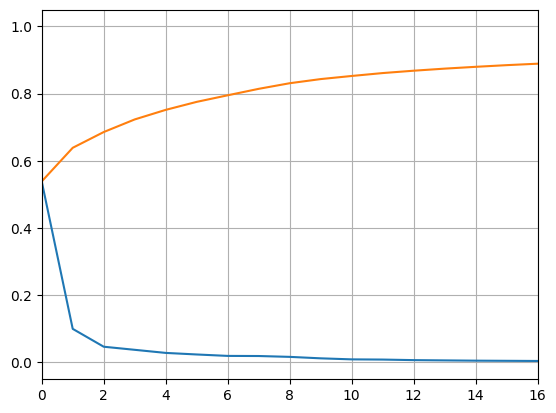

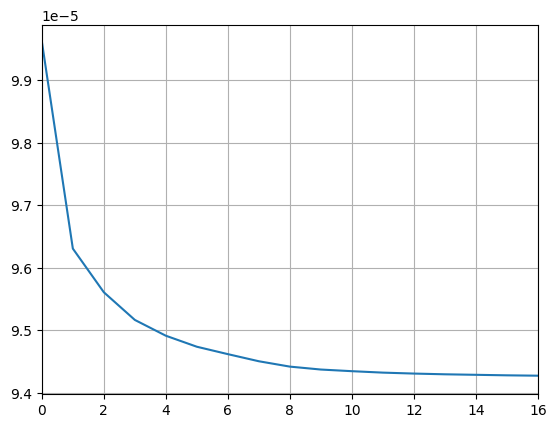

[9.96249036e-05 9.63059708e-05 9.56062734e-05 9.51630935e-05
 9.49099827e-05 9.47336304e-05 9.46150483e-05 9.45009732e-05
 9.44150917e-05 9.43682395e-05 9.43419167e-05 9.43188453e-05
 9.43037344e-05 9.42919935e-05 9.42830398e-05 9.42755184e-05
 9.42692507e-05 9.42642113e-05 9.42601664e-05 9.42578155e-05
 9.42560974e-05 9.42550422e-05 9.42540587e-05 9.42532006e-05
 9.42526101e-05 9.42521131e-05 9.42517106e-05 9.42513726e-05
 9.42510670e-05 9.42508005e-05 9.42505535e-05 9.42503190e-05
 9.42501082e-05 9.42499053e-05 9.42497175e-05 9.42495456e-05
 9.42493823e-05 9.42492272e-05 9.42490751e-05 9.42489348e-05
 9.42487969e-05 9.42486608e-05 9.42485263e-05 9.42483991e-05
 9.42482739e-05 9.42481514e-05 9.42480317e-05 9.42479131e-05
 9.42477947e-05 9.42476823e-05 9.42475745e-05 9.42474684e-05
 9.42473655e-05 9.42472638e-05 9.42471640e-05 9.42470664e-05
 9.42469707e-05 9.42468776e-05 9.42467851e-05 9.42466940e-05
 9.42466045e-05 9.42465229e-05 9.42464393e-05 9.42463520e-05
 9.42462662e-05 9.424618

In [3]:
eig_values2 = eig_values.real**2
# print(eig_values.real)
# print(eig_values2)
# print(eig_vectors[:,0].real)
contribution = eig_values/np.sum(eig_values)
cum_contribution = np.cumsum(contribution)
plt.plot(contribution)
plt.plot(cum_contribution)
plt.xlim([0, 16])
plt.grid()
plt.show()
cum_eig = np.cumsum(eig_values2)
plt.plot(cum_eig**(-1))
plt.xlim([0, 16])
plt.grid()
plt.show()
print(cum_eig**(-1))